# Phase 01: Demand Visibility & Product Segmentation

## Business Context
A global manufacturing company operates 4 central warehouses serving
customers worldwide. With 2,000+ SKUs across multiple product categories,
the operations team has no systematic way to identify which products are
driving demand volatility — leading to inefficient inventory policies
applied uniformly across all products.

## Objective
Build a demand visibility dashboard and ABC-XYZ segmentation framework
to identify the SKUs that require differentiated inventory treatment.

## Key Questions
1. What does overall demand look like across warehouses and categories?
2. Which products contribute 80% of total demand? (ABC)
3. Which products have unpredictable demand patterns? (XYZ)
4. What inventory policy should each segment follow?

## Dataset
- Source: Historical Product Demand (Kaggle — felixzhao)
- Size: ~1M records | 4 Warehouses | 2,000+ SKUs | 2011–2017

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('Blues_d')



In [2]:
# Load raw data
df = pd.read_csv('../00_data/historical_product_demand_raw.csv')

print("=" * 45)
print("  DATA INGESTION REPORT")
print("=" * 45)
print(f'Rows            :   {df.shape[0]:,}')
print(f'Columns         :   {df.shape[1]:,}')
print(f'Size            :   ~{df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print("=" * 45)
print("\nColumn names & dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

  DATA INGESTION REPORT
Rows            :   1,048,575
Columns         :   5
Size            :   ~301.6 MB

Column names & dtypes:
Product_Code        object
Warehouse           object
Product_Category    object
Date                object
Order_Demand        object
dtype: object

First 5 rows:


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


## Data Quality Investigation

Before any cleaning, we investigate each column to understand
what problems exist and WHY they exist.

Questions to answer:
- Why is `Order_Demand` stored as object instead of numeric?
- Is `Date` format consistent across all rows?
- How many missing values exist and in which columns?
- Are there negative demand values? What do they represent?

In [3]:
print("=" * 45)
print("  MISSING VALUES")
print("=" * 45)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 45)
print("  ORDER_DEMAND — WHY IS IT OBJECT?")
print("=" * 45)
# Tìm các giá trị không convert được sang số
non_numeric = pd.to_numeric(df['Order_Demand'], errors='coerce').isna()
print(f"Non-numeric rows : {non_numeric.sum():,}")
print(f"Sample values    :")
print(df.loc[non_numeric, 'Order_Demand'].value_counts().head(10))

  MISSING VALUES
      Missing Count  Missing %
Date          11239       1.07

  ORDER_DEMAND — WHY IS IT OBJECT?
Non-numeric rows : 10,469
Sample values    :
Order_Demand
(100)     1199
(200)      902
(1000)     591
(1)        542
(300)      494
(500)      438
(400)      373
(2)        367
(50)       295
(10)       259
Name: count, dtype: int64


## Investigation Results:

There are 3 issues:
- Issue 1: Date column contains 11,239 missing values (1.07% of total records).
- Issue 2: Order_Demand has 10,469 negative values in accounting format (e.g., (100)), causing pandas to parse them as object instead of numeric.
- Issue 3: All 5 columns are currently parsed as object; requires data type casting to appropriate formats.

In [4]:
# Standardize columns name
df.columns = df.columns.str.lower().str.replace(' ','_')

# Drop missing data rows of Date column
df = df.dropna(subset='date')

# Process order_demand column
df['order_demand'] = df['order_demand'].astype(str).str.replace('(','-', regex=False).str.replace(')','')

# Convert data type
df['date'] = pd.to_datetime(df['date'])
df['order_demand'] = pd.to_numeric(df['order_demand'], errors='coerce')

print(df.dtypes)
print(len(df))
print(df['order_demand'].isna().sum())

product_code                object
warehouse                   object
product_category            object
date                datetime64[ns]
order_demand                 int64
dtype: object
1037336
0


Number of Rows (date):
- Before cleaning: 1,048,575
- After cleaning: 1,037,336
- Drops: 11,239 rows (missing value)

In [5]:
# Export cleaned data
df.to_csv('../00_data/historical_demand_clean.csv', index=False)
print("✓ Exported cleaned data")

✓ Exported cleaned data


### Overview of Product Demand Trend
Based on the historical demand trend chart, we can draw three key observations regarding business operations:
- **2011 data does not reflect actual business performance:** For most of 2011 (from January to October), the recorded demand on the system was almost zero. This is likely because the system only started collecting data towards the end of the year, resulting in incomplete records. Therefore, this period should not be used to evaluate business performance.

- **Distinct Yearly Seasonality:** Market demand exhibits a very stable and repeating pattern. Specifically, order volumes tend to hit bottom during the middle of the year (Q2 - Q3) and grow strongly to reach a peak at the end of the year (Q4). Understanding this rhythm is crucial for inventory planning and optimizing warehousing costs.

- **The sudden drop in early 2017 is due to incomplete data:** The sharp decline in the chart at the beginning of 2017 does not indicate a market downturn. In reality, the data for January 2017 only covers a few days before the data recording period ended. This incomplete information does not represent the actual business situation.

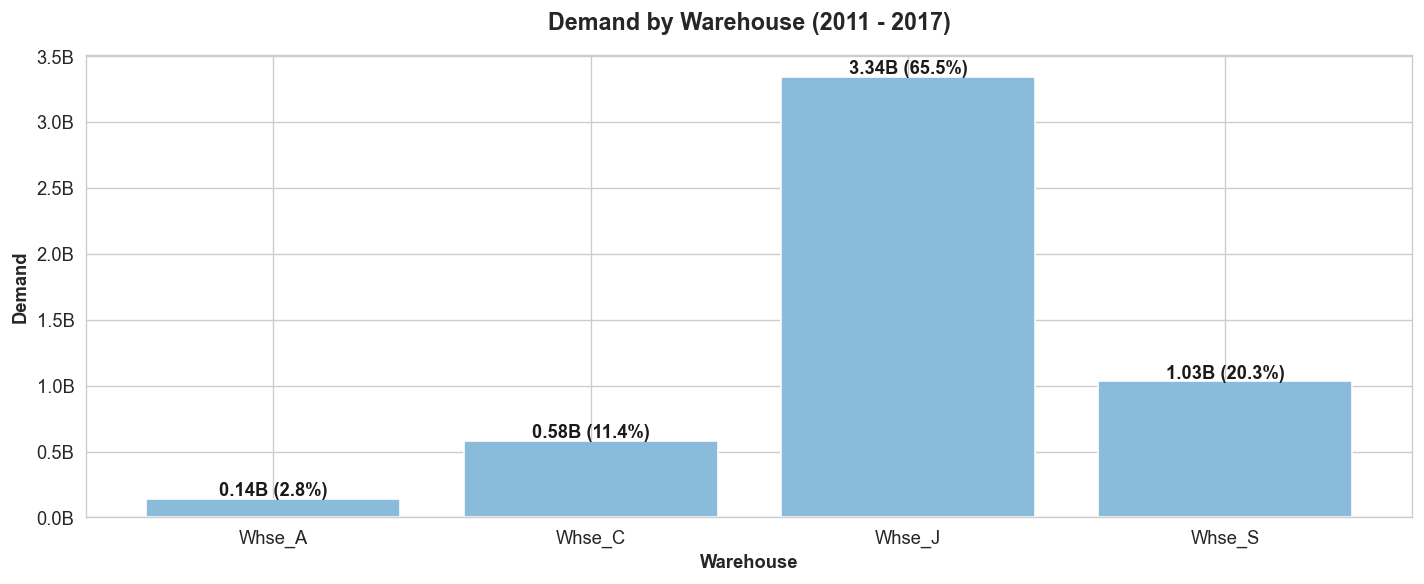

In [7]:
# Warehouse analysis
warehouse_demand = df.groupby('warehouse')['order_demand'].sum()

# Bar chart
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(warehouse_demand.index.astype(str), warehouse_demand.values)

# Labels & Title
ax.set_title('Demand by Warehouse (2011 - 2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Warehouse', fontsize=11, fontweight='bold')
ax.set_ylabel('Demand', fontsize=11, fontweight='bold')
# Adjust y-axis
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
# Data labels
wh_total_demand = warehouse_demand.sum()
for bar in bars:
    value = bar.get_height()
    pct    = value / wh_total_demand * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20000000,
        f"{bar.get_height()/1e9:.2f}B ({pct:.1f}%)",
        ha='center', fontsize=11, fontweight='bold',color='#1a1a1a'
    )
plt.tight_layout()
plt.savefig('../png/chart_02a_warehouse_barchart.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Warehouse Demand Distribution — Key Insights
The warehouse network shows a significant demand imbalance,
with one facility dominating nearly two-thirds of total volume
while another remains critically underutilized.
**1. Demand is heavily concentrated in Whse_J**
* **Observation:** Whse_J accounts for 65.5% of total demand (3.34B units), making it the single most critical node in the distribution network.
* **Implication:** Any operational disruption at this facility would severely impact the majority of the supply chain output.
* **Recommended Action:** Prioritize inventory buffer allocations and operational resilience planning for Whse_J above all other facilities.

**2. Whse_A is significantly underutilized**
* **Observation:** With only 2.8% of total demand (0.14B units), Whse_A operates at a mere fraction of the network's total capacity.
* **Implication:** This significant imbalance warrants a strategic review of its core role and cost structure relative to its current throughput.
* **Recommended Action:** Conduct a thorough cost-per-unit analysis for Whse_A to assess the financial feasibility of facility consolidation.

**3. Whse_S and Whse_C form a balanced mid-tier**
* **Observation:** Together, they contribute 31.7% of total demand (Whse_S at 20.3% and Whse_C at 11.4%).
* **Implication:** This suggests a stable secondary distribution layer that could potentially absorb additional volume if the primary node is constrained.
* **Recommended Action:** Monitor and evaluate these two facilities as potential overflow capacity for Whse_J during seasonal peak periods.

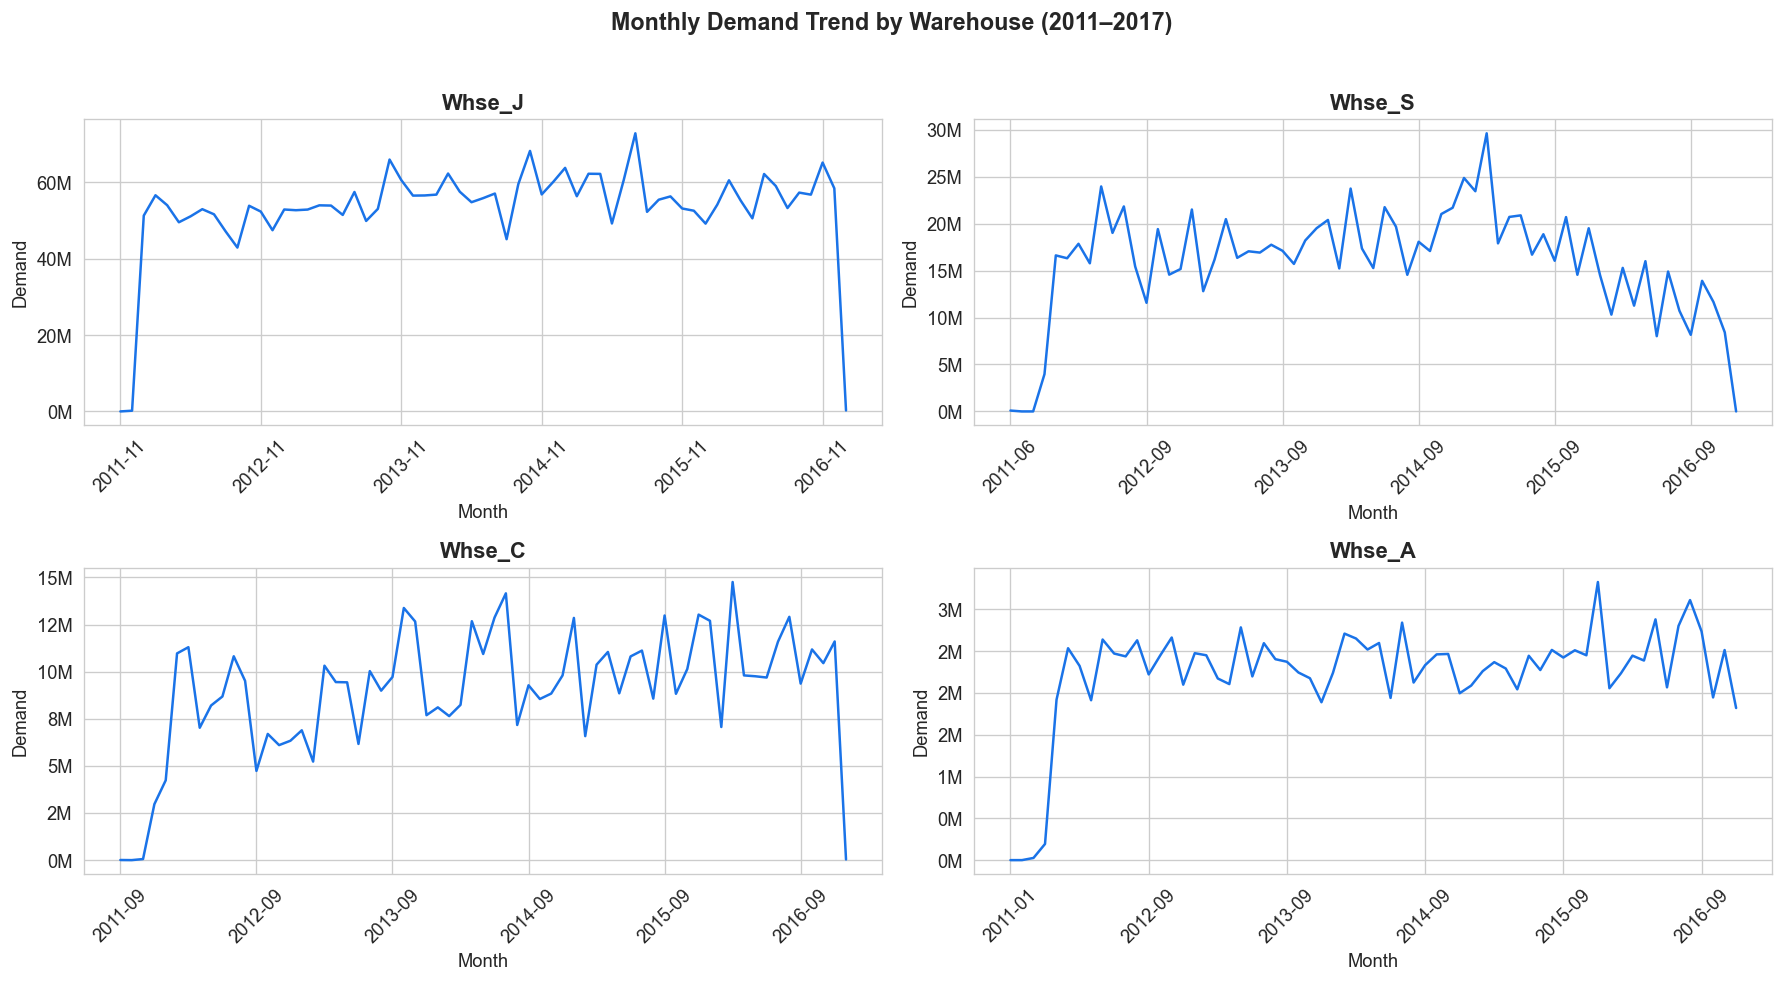

In [8]:
# Warehouse list
warehouses = df['warehouse'].unique()

# 4 subplots (2,2)
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten() # Turn into list

# Warehouse loops
for i, warehouse in enumerate(warehouses):
    df_wh = df[df['warehouse'] == warehouse]
    monthly = df_wh.groupby(df_wh['date'].dt.to_period('M'))['order_demand'].sum()

    # Subplot
    axes[i].plot(monthly.index.astype(str), monthly.values, color='#1a73e8', linewidth=1.5)
    
    # Title và labels for each subplot
    axes[i].set_title(f'{warehouse}', fontweight='bold')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Demand')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    
    # x-axis streamlining
    ticks = range(0, len(monthly), 12) # Each 12 months
    axes[i].set_xticks(list(ticks))
    axes[i].set_xticklabels(
        [str(monthly.index[j]) for j in ticks],
        rotation=45)

# Big title
fig.suptitle(
    'Monthly Demand Trend by Warehouse (2011–2017)', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../png/chart_02b_warehouse_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Monthly Demand Trend by Warehouse — Key Insights

Across all four warehouses, demand patterns diverge significantly,
indicating that a uniform inventory policy would be inadequate
for this distribution network.

**1. Whse_J shows stable, predictable seasonality.**
- Observation: Demand fluctuates consistently between 40M–70M
  units/month with a clear yearly cycle — peaking in Q4 and
  dropping in Q2/Q3 throughout the entire period.
- Implication: High cyclicality with low noise indicates a
  mature, well-established demand pattern.
- Action: Use Whse_J as the primary baseline for forecasting
  model training and accuracy benchmarking in Project 3.

**2. Whse_S exhibits a prolonged structural decline.**
- Observation: Demand peaked at ~30M units/month in late 2014
  and has declined continuously to ~10M by mid-2016 — a 67%
  reduction over two years.
- Implication: This is not seasonal variation but a structural
  shift, potentially driven by customer migration or volume
  redistribution across the network.
- Action: Validate root cause with Operations before applying
  time-series forecasting, to prevent models from extrapolating
  the decline into negative territory.

**3. Whse_C displays the highest demand volatility.**
- Observation: Monthly demand swings frequently between 5M and
  15M units — a 3x variation within short timeframes — with no
  discernible seasonal pattern.
- Implication: This unpredictability creates elevated stockout
  and overstock risk compared to other facilities.
- Action: Apply dynamic safety stock calculation for Whse_C
  in Project 2, using a higher service level target to buffer
  against volatility.

**4. Whse_A operates at negligible scale.**
- Observation: Demand remains consistently low throughout the
  entire period, with minimal month-to-month variation.
- Implication: Low volume with low variability suggests this
  facility handles a very specific, stable product mix.
- Action: Treat Whse_A as low priority in forecasting efforts;
  simple Naive or Seasonal Naive models likely sufficient.

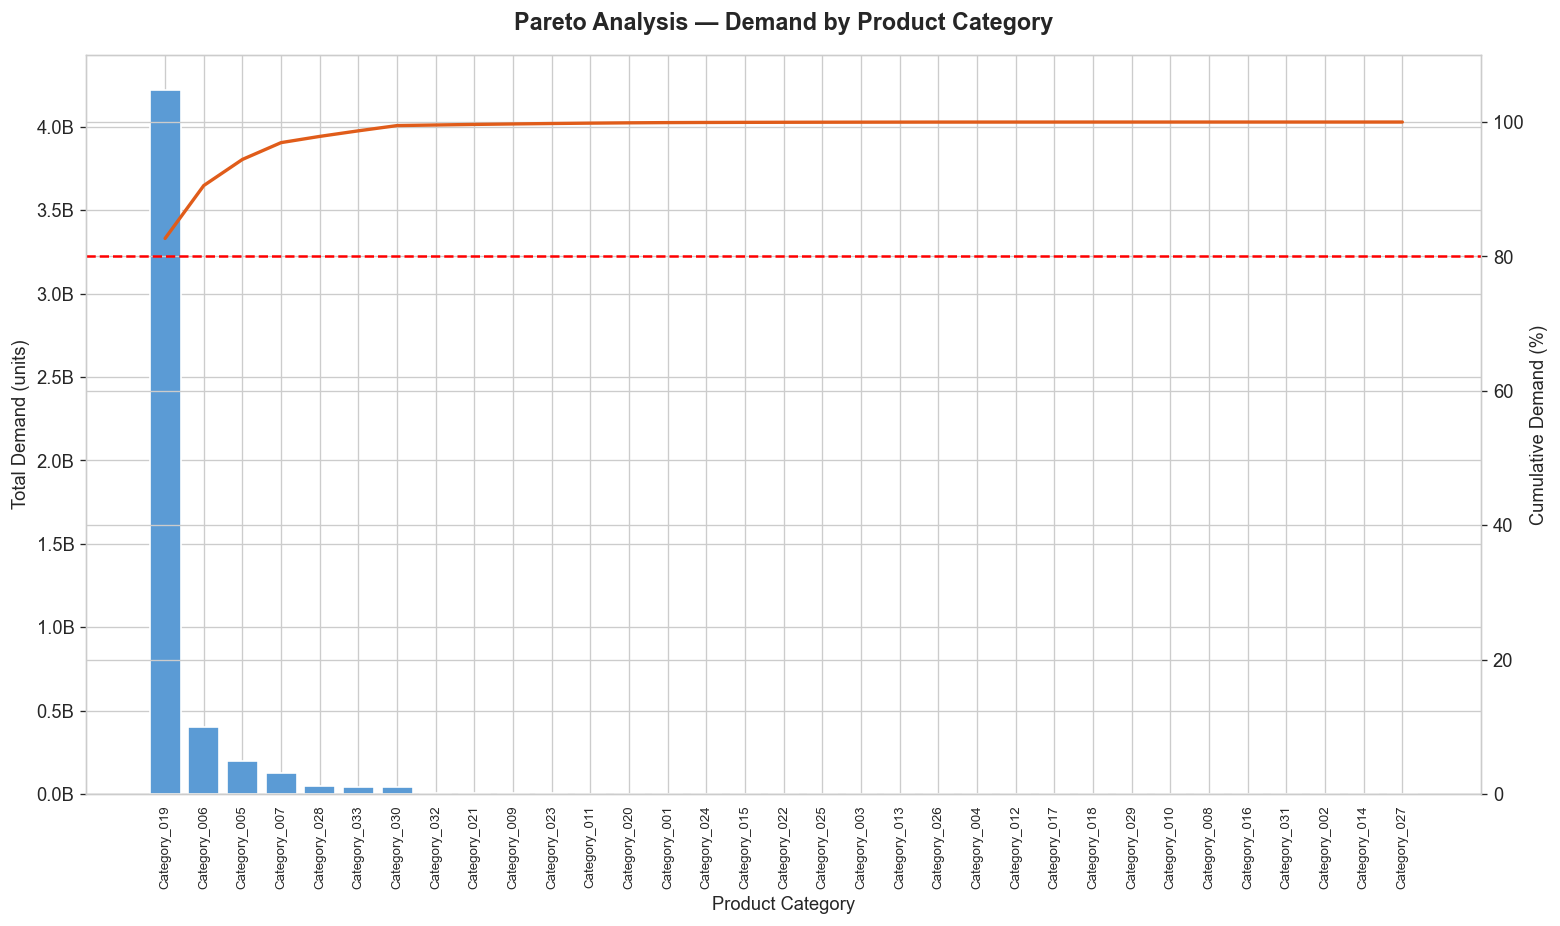

In [9]:
# Demand by product category
ctg_demand = df.groupby('product_category')['order_demand'].sum().sort_values(ascending=False)
ctg_total = ctg_demand.sum()
ctg_cumul_pct = ctg_demand.cumsum() / ctg_total * 100

# Visualize
fig, ax1 = plt.subplots(figsize=(15,8))
ax2 = ax1.twinx()

bars = ax1.bar(ctg_demand.index.astype(str), ctg_demand.values, color='#5B9BD5') # Bar chart
ax2.plot(ctg_demand.index.astype(str), ctg_cumul_pct.values, color='#E05C1A', linewidth=2) # Line chart
ax2.set_ylim(0, 110)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=1.5) #80% line

# Titles and Labels
ax1.set_title('Pareto Analysis — Demand by Product Category', 
              fontweight='bold', fontsize=14, pad=15)
ax1.set_xlabel('Product Category', fontsize=11)
ax1.set_ylabel('Total Demand (units)', fontsize=11)
ax2.set_ylabel('Cumulative Demand (%)', fontsize=11)

# Adjust y-axis
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e9:.1f}B'))

# Adjust x-axis
ax1.set_xticks(range(len(ctg_demand)))
ax1.set_xticklabels(ctg_demand.index.tolist(), rotation=90, fontsize=8)

plt.show()


### Product Category Pareto Analysis — Key Insights

**1. Category_019 exhibits extreme dominance (Hyper-Pareto).**
- **Observation:** Category_019 single-handedly drives over 80% of the total unit demand (>4.0B units), far exceeding the typical 80/20 rule.
* **Implication:** The company's revenue and supply chain are critically dependent on this single category. Any stockout or supply disruption here represents a catastrophic business risk.
- **Recommended Action:** Allocate dedicated planners, implement the highest forecasting rigor, and secure priority supplier capacities exclusively for Category_019 (Class A+).

**2. The portfolio is highly concentrated in top 4 categories.**
- **Observation:** Adding just three more categories (006, 005, 007) pushes the cumulative demand to 96.94%. 
- **Implication:** Applying a "one-size-fits-all" inventory strategy across all categories would result in massive misallocation of working capital and warehouse space.
- **Recommended Action:** Implement strict ABC Inventory Classification. Focus manual planning efforts on the top 4 categories, while automating replenishment for the rest.

**3. A massive "Long Tail" of unproductive categories exists.**
- **Observation:** 29 categories (from Category_028 onwards) have near-zero demand volume but still exist in the portfolio.
- **Implication:** These slow-moving items tie up working capital, consume valuable warehouse slots, and add hidden administrative costs without generating meaningful volume.
- **Recommended Action:** Conduct an immediate SKU/Category rationalization review. Consider phasing out, liquidating, or shifting these low-performing categories to a Make-to-Order (MTO) model.

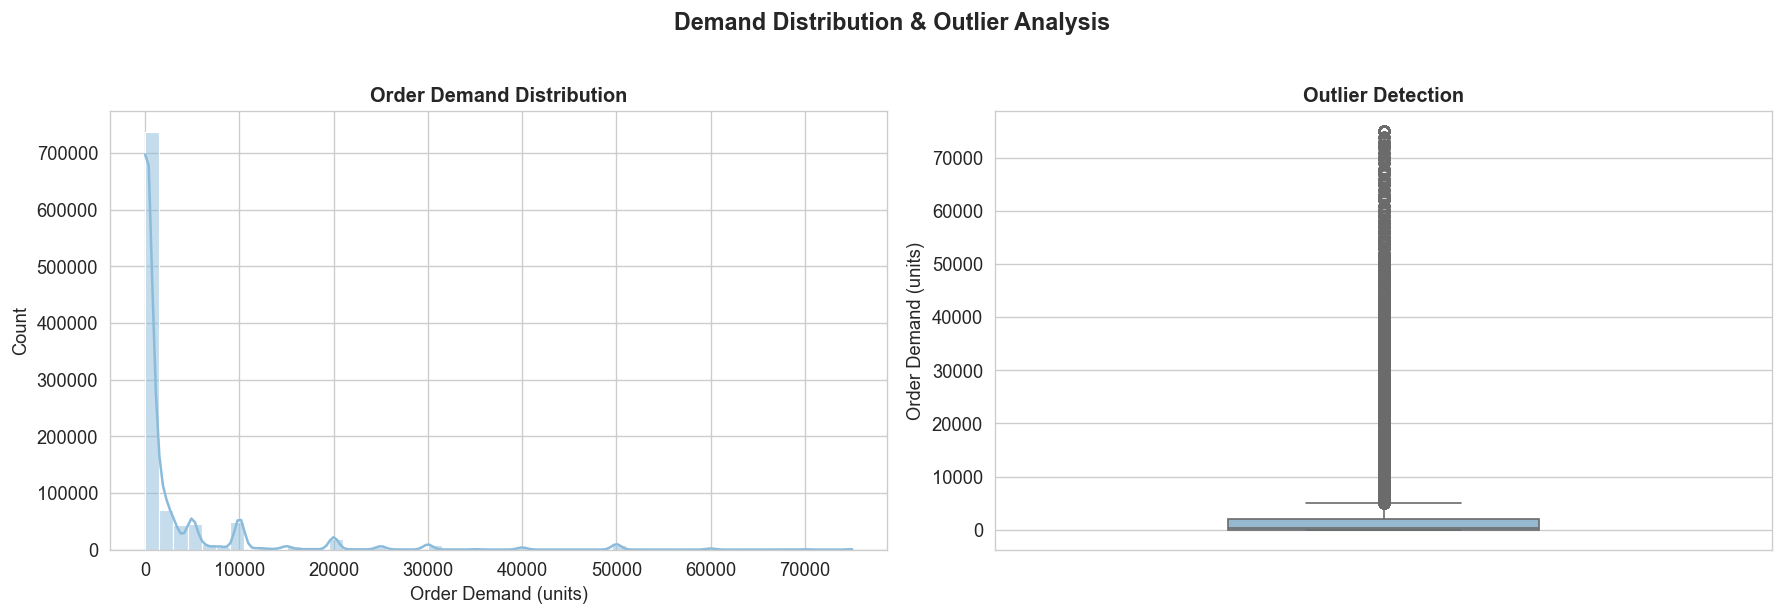

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
lower_limit = df['order_demand'].quantile(0.01)  # = 0
upper_limit = df['order_demand'].quantile(0.99)
df_viz = df[(df['order_demand'] >= lower_limit) & (df['order_demand'] <= upper_limit)]

# Histogram chart for demand distribution
sns.histplot(data=df_viz, x='order_demand', bins=50, kde=True, ax=ax1)

# Boxplot for outliers detection
sns.boxplot(data=df_viz, y='order_demand', width=0.4, ax=ax2)

# Titles each subplots
ax1.set_title('Order Demand Distribution', 
              fontweight='bold', fontsize=12)
ax2.set_title('Outlier Detection', 
              fontweight='bold', fontsize=12)

# Labels
ax1.set_xlabel('Order Demand (units)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax2.set_ylabel('Order Demand (units)', fontsize=11)

# Title
fig.suptitle('Demand Distribution & Outlier Analysis', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../png/chart_04_distribution_outliers.png',
            dpi=150, bbox_inches='tight')
plt.show()
plt.show()

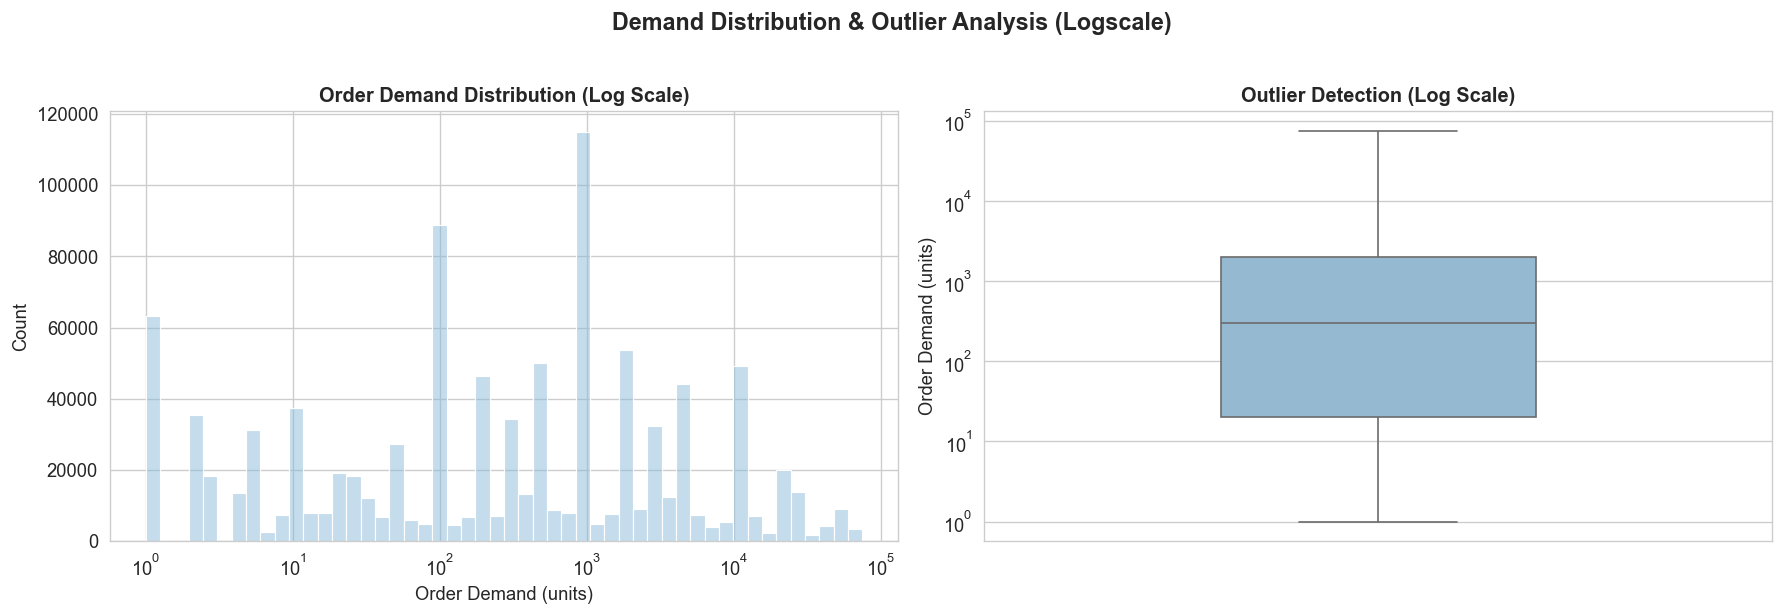

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
lower_limit = df['order_demand'].quantile(0.01)  # = 0
upper_limit = df['order_demand'].quantile(0.99)
df_viz = df[(df['order_demand'] >= lower_limit) & (df['order_demand'] <= upper_limit)]

# Histogram chart for demand distribution
sns.histplot(data=df_viz, x='order_demand', bins=50, kde=True, ax=ax1, log_scale=True)

# Boxplot for outliers detection
sns.boxplot(data=df_viz, y='order_demand', width=0.4, ax=ax2, log_scale=True)

# Titles each subplots
ax1.set_title('Order Demand Distribution (Log Scale)', 
              fontweight='bold', fontsize=12)
ax2.set_title('Outlier Detection (Log Scale)', 
              fontweight='bold', fontsize=12)

# Labels
ax1.set_xlabel('Order Demand (units)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax2.set_ylabel('Order Demand (units)', fontsize=11)

# Title
fig.suptitle('Demand Distribution & Outlier Analysis (Logscale)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../png/chart_04_distribution_outliers(logscale).png',
            dpi=150, bbox_inches='tight')
plt.show()


### Order Demand Distribution & Outliers Analysis — Key Insights

**1. Demand distribution is extremely right-skewed.**
- **Observation:** The histogram reveals that the vast majority of orders have very small quantities (clustering densely near zero), creating a long tail stretching to the right. 
- **Implication:** Traditional forecasting models that assume a normal distribution (bell curve) will struggle to learn from this data, leading to over-forecasting the baseline and under-forecasting the peaks.
- **Recommended Action:** Apply mathematical transformations (e.g., Log or Box-Cox transformation) to normalize the data distribution before training, or utilize non-linear tree-based models (like XGBoost or Random Forest) that are robust to skewness.

**2. Extreme outliers likely represent valid, sporadic bulk orders.**
- **Observation:** The boxplot shows a dense, towering column of outliers extending far beyond the typical Interquartile Range (IQR), with maximums reaching 70,000+ units.
- **Implication:** In a fulfillment context, these are rarely data entry errors; they are valid B2B wholesale or promotional orders. However, feeding them directly into the algorithm will artificially inflate the mean demand and distort baseline inventory calculations.
- **Recommended Action:** Cap (clip) these extreme values at a specific threshold (e.g., 95th or 99th percentile) to train the baseline model. Handle these massive bulk orders through a separate, manual "exception management" process.

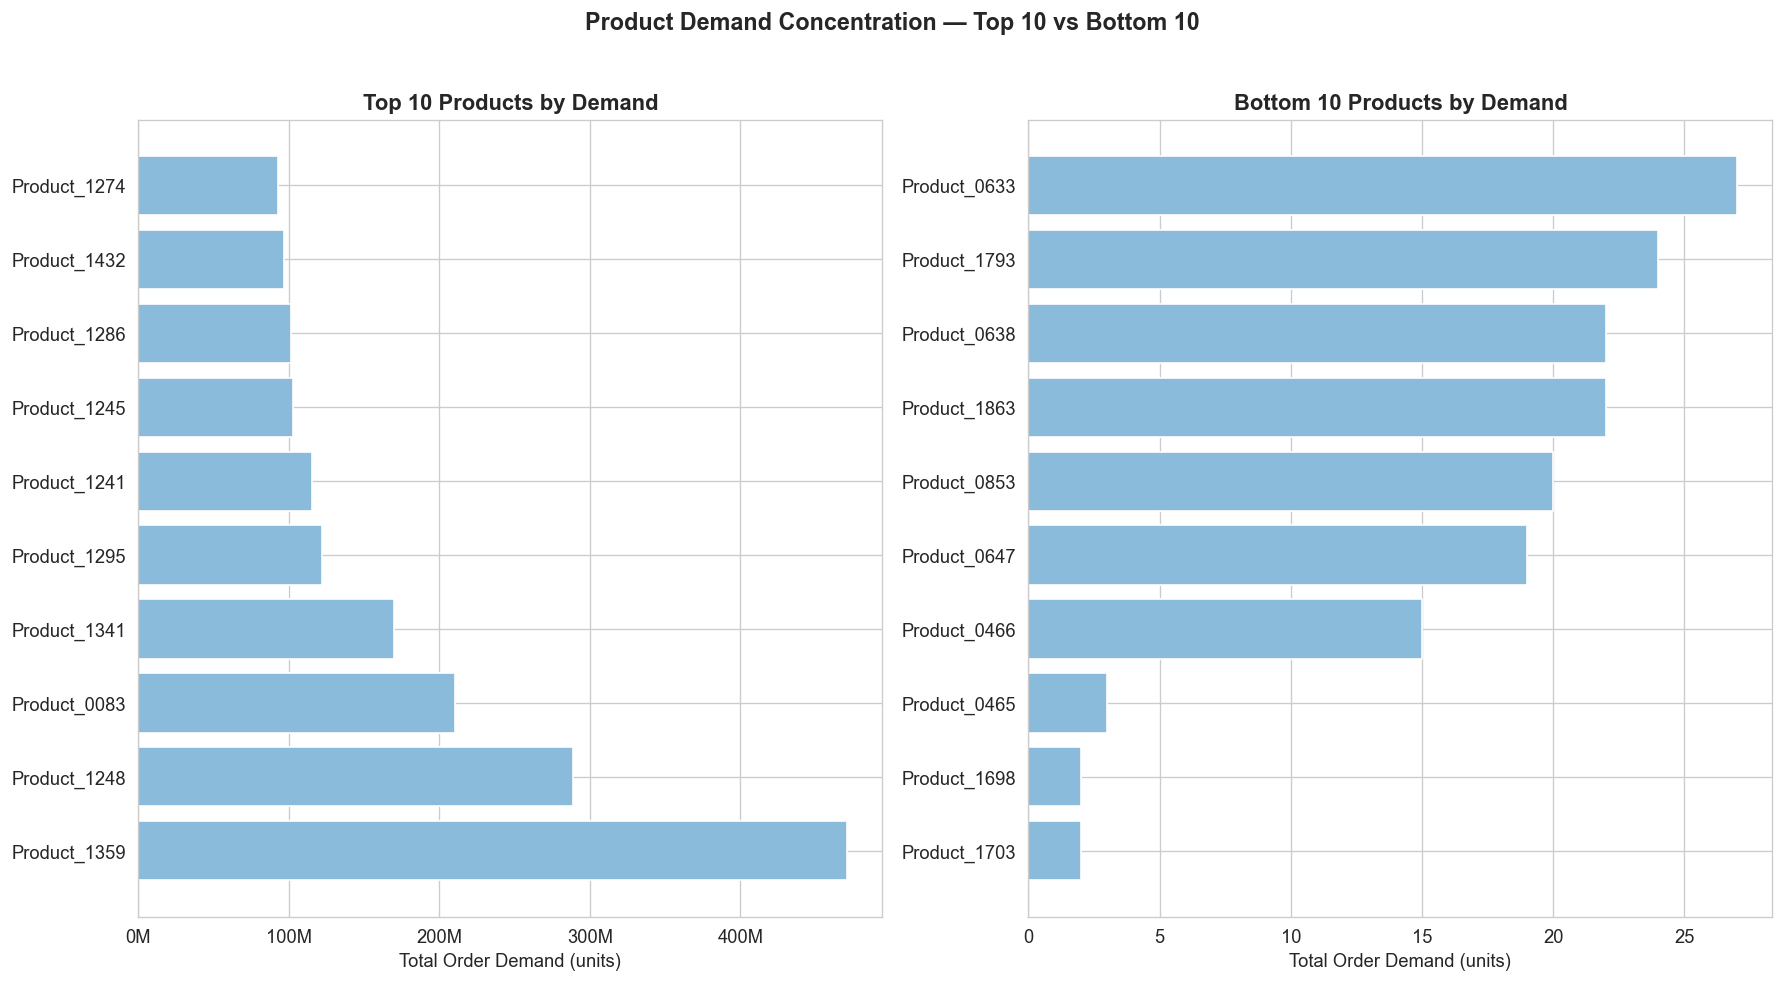

In [12]:
# Top 10 & Bottom 10 Products
top10_product = df.groupby('product_code')['order_demand'].sum().sort_values(ascending=False).head(10)
bot10_product = df.groupby('product_code')['order_demand'].sum().sort_values(ascending=True).head(10)

# Horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Top 10 Products chart
ax1.barh(top10_product.index.astype(str), top10_product.values)
ax1.set_title('Top 10 Products by Demand', fontweight='bold')
ax1.set_xlabel('Total Order Demand (units)')

# Bottom 10 Products chart
ax2.barh(bot10_product.index.astype(str), bot10_product.values)
ax2.set_title('Bottom 10 Products by Demand', fontweight='bold')
ax2.set_xlabel('Total Order Demand (units)')

# Format x-axis
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

fig.suptitle('Product Demand Concentration — Top 10 vs Bottom 10',
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig('../png/chart_05_top_bottom_products.png',
            dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()


### Product Demand Concentration (Top 10 vs Bottom 10) — Key Insights

**1. Extreme concentration at the top (Product_1359 dominance).**
- **Observation:** The top 10 products drive an overwhelming volume of demand. `Product_1359` alone generates nearly 470 million units, accounting for 9.2% of the total network demand.
- **Implication:** The company's core volume relies heavily on a handful of "mega-runners". Any supply disruption, forecasting error, or stockout for these specific SKUs will immediately and severely impact top-line revenue and service levels.
- **Recommended Action:** Assign dedicated planners for these Top 10 SKUs, secure priority manufacturing/supplier capacity, and maintain rigorous safety stock buffers.

**2. The Bottom 10 are "nearly inactive," not just slow-movers.**
- **Observation:** The bottom 10 products recorded a microscopic demand of only 1 to 23 units *in total over a 6-year period*. 
- **Implication:** These are not typical slow-moving items; they are effectively dead stock or "nearly inactive" SKUs. Keeping them in the active portfolio causes SKU proliferation, consumes valuable warehouse racking space, and drains working capital through hidden holding costs without generating value.
- **Recommended Action:** Execute an immediate SKU rationalization. Delist or liquidate these items. If they must be kept for strategic reasons, transition them strictly to a Make-to-Order (MTO) supply model.

**3. The massive volume gap necessitates Inventory Segmentation.**
- **Observation:** There is a staggering disparity in the dataset—ranging from a product moving 470,000,000 units to one moving just 2 units over the same timeframe.
- **Implication:** Applying a "one-size-fits-all" forecasting model or a uniform inventory policy across this portfolio is fundamentally flawed and financially detrimental. 
- **Recommended Action:** Proceed immediately to an **ABC-XYZ Analysis**. Segment the portfolio to tailor forecasting algorithms and safety stock rules based on each SKU's specific volume (ABC) and demand volatility (XYZ).

  abc_class  product_count  total_demand
0         A             84    4074045350
1         B            202     774548889
2         C           1874     255257992


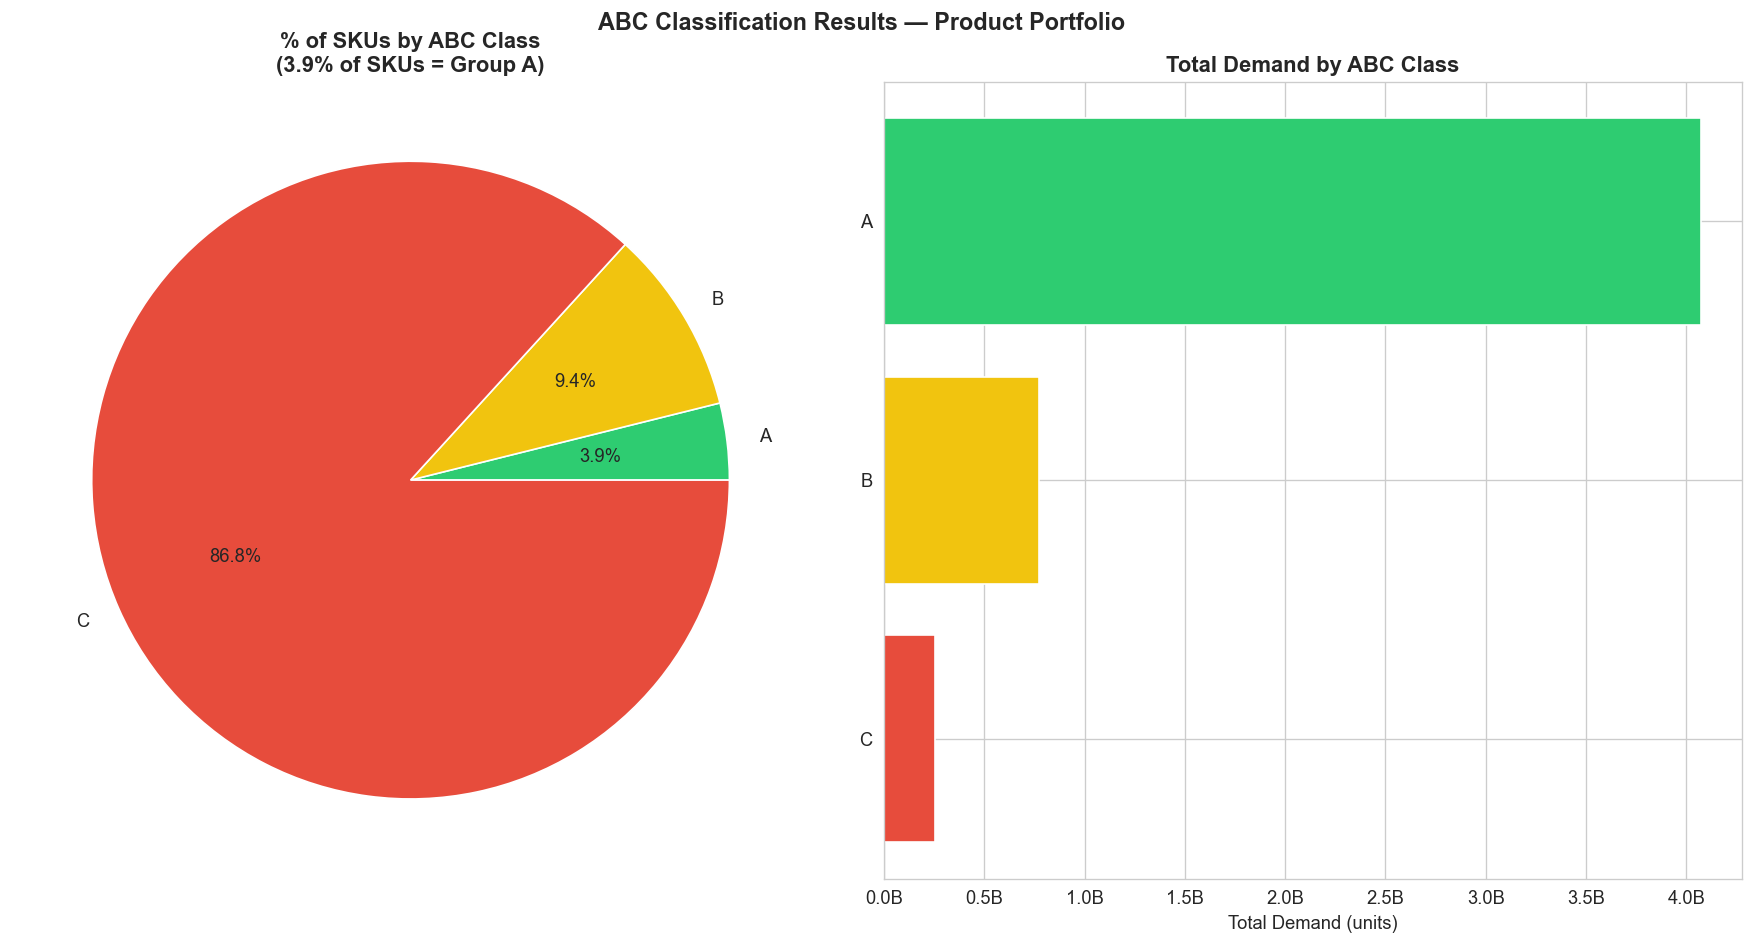

In [59]:
# Demand by Products
product_demand = df.groupby('product_code')['order_demand'].sum().sort_values(ascending=False).reset_index()
product_demand.columns = ['product_code', 'total_demand']
product_demand['cumulative_pct'] = (product_demand['total_demand'].cumsum() / product_demand['total_demand'].sum() * 100)

# Conditions and Choices
conditions = [
    product_demand['cumulative_pct'] <= 80,
    product_demand['cumulative_pct'] <= 95
]
choices = ['A', 'B']
product_demand['abc_class'] = np.select(conditions, choices, default='C')

# abc_class
abc_summary = product_demand.groupby('abc_class').agg(
    product_count = ('product_code', 'count'),
    total_demand  = ('total_demand', 'sum')).reset_index()
print(abc_summary)
# CHARTS
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# Pie chart
axes[0].pie(abc_summary['product_count'], labels=abc_summary['abc_class'], colors=['#2ecc71', '#f1c40f', '#e74c3c'], autopct='%1.1f%%' )
axes[0].set_title('% of SKUs by ABC Class\n(3.9% of SKUs = Group A)', 
                  fontweight='bold')
# Bar chart
axes[1].barh(abc_summary['abc_class'], abc_summary['total_demand'].values,color=['#2ecc71', '#f1c40f', '#e74c3c'])
axes[1].set_title('Total Demand by ABC Class', fontweight='bold')
axes[1].set_xlabel('Total Demand (units)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].invert_yaxis()

# Figure title
fig.suptitle('ABC Classification Results — Product Portfolio', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../png/chart_06_abc_classification.png',dpi=150, bbox_inches='tight')
plt.show()

### ABC Classification Results — Key Insights

**1. Group A represents a "Hyper-Pareto" concentration.**
- **Observation:** A mere 3.9% of the total SKUs make up Group A, yet they drive ~79.8% of total demand (4.07B out of 5.10B units).
- **Implication:** The company's core operations and service levels are highly sensitive to the availability of this tiny fraction of products. Any stockout in this 3.9% will severely disrupt fulfillment and revenue.
- **Recommended Action:** Apply the most rigorous inventory controls. Assign dedicated manual planning, maintain high safety stock buffers, and target the highest service levels (e.g., 98%+) exclusively for Group A.

**2. Group C is a massive drain on operational resources.**
- **Observation:** A staggering 86.8% of the product portfolio falls into Group C, but contributes only a marginal fraction of the total demand.
- **Implication:** This "trivial many" heavily ties up working capital, consumes premium warehouse racking space, and adds hidden administrative costs while generating negligible volume.
- **Recommended Action:** Automate replenishment rules for Group C to minimize manual touchpoints. Initiate a strategic SKU rationalization review to phase out dead stock or shift to a Make-to-Order (MTO) model.

**3. Uniform inventory policies are fundamentally inefficient.**
- **Observation:** The stark contrast between the pie chart (portfolio size) and the bar chart (demand volume) highlights a severe mismatch in how demand is generated.
- **Implication:** Managing all 2,000+ SKUs with a "one-size-fits-all" strategy leads to over-investing in slow-movers (C) and under-protecting high-runners (A).
- **Recommended Action:** Fully operationalize ABC segmentation across the warehouse: redesign the physical layout (placing Group A items closest to shipping docks) and apply different forecasting algorithms based on class.

   product_code  mean_demand  std_demand   cv xyz_class
0  Product_0001     7,416.39    3,859.46 0.52         Y
1  Product_0002   143,540.98  144,039.50 1.00         Z
2  Product_0003     1,961.67    1,529.94 0.78         Y
3  Product_0004     2,175.44    1,743.90 0.80         Y
4  Product_0005       655.88      689.84 1.05         Z
5  Product_0006       281.48      166.50 0.59         Y
6  Product_0007     3,353.33    1,528.32 0.46         X
7  Product_0008     8,425.00    4,484.27 0.53         Y
8  Product_0009       850.91      580.51 0.68         Y
9  Product_0010     1,442.37    1,029.93 0.71         Y
xyz_class
X     271
Y    1147
Z     742
Name: product_code, dtype: int64


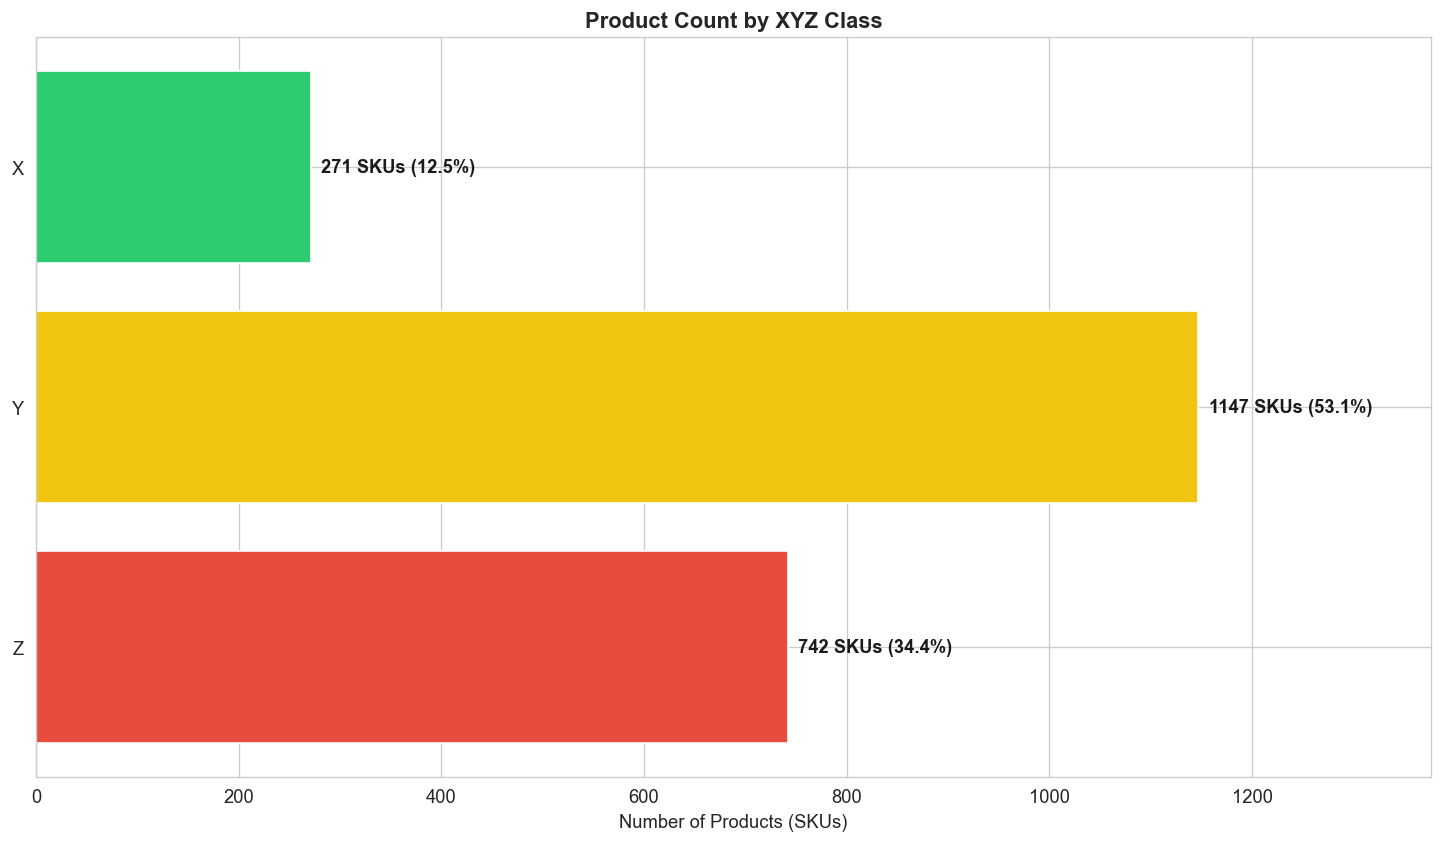

In [57]:
# Aggregate monthly demand per product
product_monthly_demand = df.groupby(['product_code', df['date'].dt.to_period('M')])['order_demand'].sum().reset_index()

# CV per product
xyz_stats = product_monthly_demand.groupby('product_code')['order_demand'].agg(
    mean_demand = 'mean',
    std_demand = 'std').reset_index()

# CV calculations and Filters
xyz_stats['cv'] = xyz_stats['std_demand'] /  xyz_stats['mean_demand']
xyz_stats = xyz_stats[xyz_stats['mean_demand'] > 0]

conditions = [
    xyz_stats['cv'] < 0.5,
    xyz_stats['cv'] >= 1.0]
choices = ['X', 'Z']
xyz_stats['xyz_class'] = np.select(conditions, choices, default='Y')

print(xyz_stats.head(10))
print(xyz_stats.groupby('xyz_class')['product_code'].count())

# VISUALIZE
# Data
xyz_summary = xyz_stats.groupby('xyz_class').agg(product_count = ('product_code', 'count')).reset_index()

# Figure
fig, ax = plt.subplots(figsize=(15,8))
bars = ax.barh(xyz_summary['xyz_class'], xyz_summary['product_count'].values, color=['#2ecc71', '#f1c40f', '#e74c3c'])
ax.set_title('Product Count by XYZ Class', fontweight='bold')
# Axis labels
ax.set_xlabel('Number of Products (SKUs)')
ax.set_xlim(0, xyz_summary['product_count'].max() * 1.2)
ax.invert_yaxis()
# Data labels
prd_total_demand = xyz_summary['product_count'].sum()
for bar in bars:
    value = bar.get_width()
    pct    = value / prd_total_demand * 100
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)} SKUs ({pct:.1f}%)",
        va='center', fontsize=11, fontweight='bold',color='#1a1a1a')

plt.show()



### XYZ Classification (Demand Volatility) — Key Insights

**1. Class Y dominates the portfolio (Volatility is the norm).**
- **Observation:** More than half of the product portfolio (53.1%, 1,147 SKUs) falls into Class Y, representing items with fluctuating, seasonal, or trend-driven demand.
- **Implication:** The business operates in a highly dynamic environment. Relying on simple historical averages (static forecasting) for the bulk of the portfolio will result in significant forecast errors and imbalanced inventory.
- **Recommended Action:** Deploy advanced time-series forecasting models capable of capturing seasonality and trends. Transition from static safety stock to dynamic safety stock policies for this group.

**2. A substantial Class Z indicates high forecasting difficulty.**
- **Observation:** A massive 34.4% of SKUs (742 items) are categorized as Class Z, characterized by highly erratic, lumpy, and unpredictable demand.
* **Implication:** Applying standard mathematical forecasting algorithms to this group is mathematically futile and will only generate "noise," leading to either severe overstocking or stockouts. 
- **Recommended Action:** Stop wasting computational power on complex forecasting for Class Z. Manage these items via qualitative inputs (sales team insights), shift to a Make-to-Order (MTO) strategy, or utilize centralized inventory pooling.

**3. The scarcity of stable Class X products.**
- **Observation:** Only a small fraction of the portfolio (12.5%, 271 SKUs) exhibits highly stable and predictable demand patterns.
- **Implication:** The "easy wins" for demand planning are very limited. The planners cannot rely on steady baselines to buffer against operational inefficiencies across the broader network.
- **Recommended Action:** Put Class X items strictly on "autopilot". Fully automate their forecasting and replenishment (e.g., using simple Moving Averages) to free up human planner bandwidth to tackle the volatile Y and Z items.

abc_xyz_class
CY    1034
CZ     711
CX     129
BY      90
BX      85
AX      57
BZ      27
AY      23
AZ       4
Name: count, dtype: int64

Tổng products: 2160
xyz_class    X     Y    Z
abc_class                
A           57    23    4
B           85    90   27
C          129  1034  711


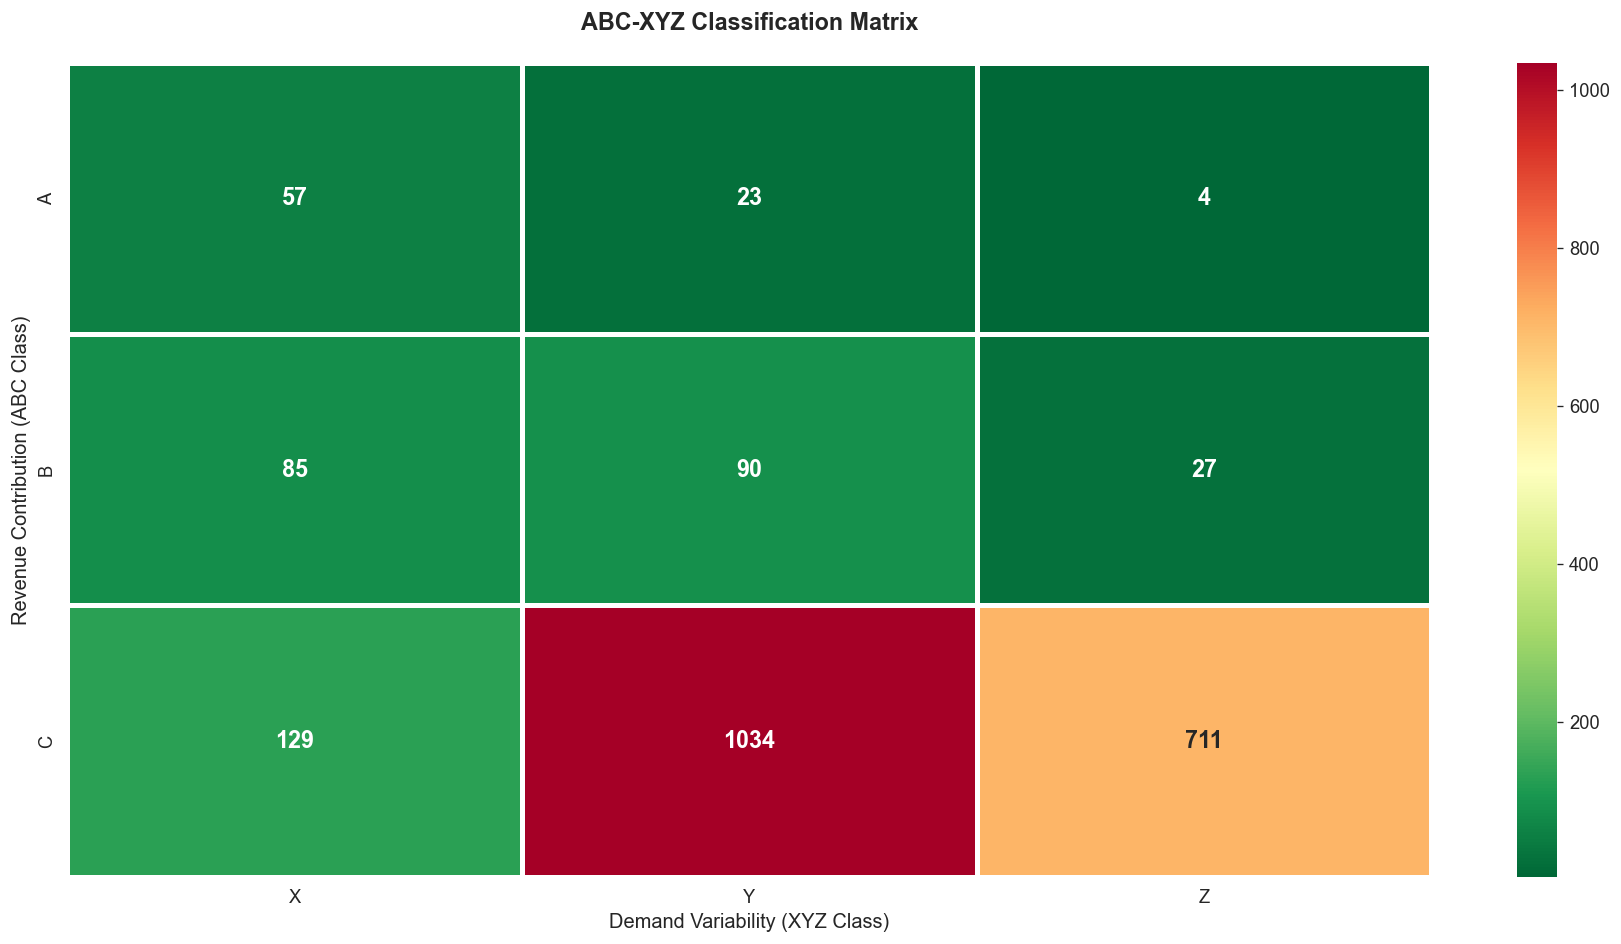

In [64]:
# product_demand có abc_class
# xyz_stats có xyz_class
# Merge theo product_code

# Merge abc class & xyz class
abc_xyz = product_demand[['product_code', 'total_demand', 'abc_class']].merge(
    xyz_stats[['product_code', 'cv', 'xyz_class']],
    on='product_code',
    how='inner')

# Creat abc_xyz column
abc_xyz['abc_xyz_class'] = abc_xyz['abc_class'] + abc_xyz['xyz_class']

# Pivot table
matrix = abc_xyz.groupby(['abc_class', 'xyz_class']).size().unstack(fill_value=0)

# Pivot table sorting
matrix = matrix.reindex(index=['A','B','C'], 
                        columns=['X','Y','Z'])
print(abc_xyz['abc_xyz_class'].value_counts())
print(f"\nTổng products: {len(abc_xyz)}")
print(matrix)

# VISUALIZE
fig, ax = plt.subplots(figsize=(15, 8))
# Heatmap
sns.heatmap(
    matrix,
    annot=True,          # hiển thị số trong từng ô
    fmt='d',             # format số nguyên
    cmap='RdYlGn_r',    # màu: đỏ = nhiều/rủi ro, xanh = ít/ổn định
    linewidths=2,        # đường kẻ giữa các ô
    linecolor='white',
    ax=ax,
    annot_kws={'size': 14, 'weight': 'bold'})

# Title & Labels
ax.set_title('ABC-XYZ Classification Matrix', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Demand Variability (XYZ Class)', fontsize=12) 
ax.set_ylabel('Revenue Contribution (ABC Class)', fontsize=12)

plt.tight_layout()
plt.savefig('../png/chart_07_abcxyz_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
policy_table = pd.DataFrame({
    'abc_xyz_class': ['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ'],
    'product_count': [57, 23, 4, 85, 90, 27, 129, 1034, 711],
    'inventory_policy': [
        'High service level (98%+), lean safety stock',      # AX
        'High service level (98%+), seasonal buffer',        # AY
        'High safety stock, strict manual oversight',        # AZ 
        'Standard service level (95%), automated reorder',   # BX
        'Standard service level (95%), seasonal buffer',     # BY
        'High buffer or transition to Make-to-Order (MTO)',  # BZ
        'Cost-driven, fully automated Reorder Point (ROP)',  # CX
        'Minimal stock, candidate for SKU rationalization',  # CY
        'Strict Make-to-Order (MTO) or phase-out/delist',    # CZ
    ],
    'forecasting_method': [
        'Moving Average / Simple ETS',               # AX
        'Prophet / Seasonal ETS',                    # AY
        'Qualitative consensus / Scenario planning', # AZ
        'Moving Average / Simple ETS',               # BX
        'Prophet / Seasonal ETS (Automated)',        # BY
        'Exception-based / Qualitative inputs',      # BZ
        'Naive forecast / Simple Moving Average',    # CX
        'Basic seasonal baseline (Zero-touch)',      # CY
        'No mathematical forecasting (Reactive)',    # CZ
    ],
    'priority': [2, 3, 1, 4, 5, 6, 7, 8, 9] 
})

policy_table.to_csv('../00_data/abc_xyz_policy_table.csv', index=False)
print("✓ Policy table exported")

✓ Policy table exported


## Executive Summary

### Business Problem
A global manufacturing company operating 4 central warehouses and 2,160+ SKUs had no systematic framework to differentiate inventory management across its product portfolio — resulting in uniform policies applied to products with vastly different demand volumes and volatility profiles.

### Key Findings
- **Network Vulnerability:** Demand is heavily concentrated geographically, with Whse_J single-handedly processing 65.5% of the total network volume (3.34B units).
- **Hyper-Pareto Category:** Category_019 dominates the product category portfolio, driving 82.7% of total unit demand (4.2B out of 5.1B units), exposing the business to massive single-category supply risks.
- **Extreme SKU Imbalance (ABC):** A mere 3.9% of SKUs (Group A) generate nearly 80% of the total demand, while a massive "long tail" of nearly inactive items (Group C) accounts for 86.8% of SKUs but only ~5% of volume.
- **High Demand Volatility (XYZ):** Over a third of the portfolio (34.4% of SKUs) falls into Group Z, characterized by highly erratic, unpredictable demand that traditional forecasting algorithms cannot reliably predict.
- **The "Danger Zone":** Cross-classification identified 4 critical "AZ" SKUs—representing high revenue impact combined with extreme unpredictability. These 4 items pose the absolute highest risk of stockouts and financial loss.

### Strategic Recommendations
- **Prioritize Risk Management for AZ & A Items:** Instantly isolate the 4 "AZ" products for strict manual oversight, qualitative sales consensus, and high safety stock buffers. Assign dedicated planners to manage all Group A items to fiercely protect the core revenue stream.
- **Rationalize the "Long Tail" (CZ & CY Items):** Stop applying standard stocking rules to the bottom 86.8% of the portfolio. Transition Group Z items to a strict Make-to-Order (MTO) model and initiate a severe SKU rationalization review to eliminate dead stock and free up working capital.
- **Deploy Segmented Forecasting Policies:** Cease the "one-size-fits-all" algorithm approach. Automate forecasting for stable items (Group X), deploy seasonal models (like Prophet/ETS) for Group Y, and shift to exception-based reactive planning for erratic items (Group Z).

### Next Steps — Project 2
Having established the segmentation framework, Project 2 will leverage these classifications to diagnose the root causes of demand volatility and quantify their cost impact. Using seasonal decomposition and safety stock modeling, we will translate the ABC-XYZ findings into concrete inventory cost savings — particularly for the high-risk AZ and BZ segments.